# Analisi Diffusione COVID-19
Il committente richiede di avere un report su casi e vaccinazioni in diverse aree del mondo; a tal fine, richiede di utilizzare i dati, raccolti e curati da Our World in Data, all'indirizzo https://github.com/owid/covid-19-data/tree/master/public/data dove si trovano le informazioni relative. In particolare, il dataset si può scaricare dalla piattaforma o dall’indirizzo https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

URL = "https://raw.githubusercontent.com/owid/covid-19-data/refs/heads/master/public/data/owid-covid-data.csv"

try:
    df = pd.read_csv(URL)
    print(f"\n--- QUESITO 1: Verifica  dataset e metadati ---")
    print(f"Dataset caricato con successo.")
    print(f"Dimensioni del dataset: {df.shape[0]} righe e {df.shape[1]} colonne.")
except Exception as e:
    print(f"Errore critico durante il caricamento: {e}")
    print(f"\nAnalisi Strutturale dei Metadati:")
df.info(verbose=False, memory_usage="deep") # info natura dati
record_aggregati = df['continent'].isnull().sum() # conta record di "continet" risulta NaN
print(f"\nDiagnostica anomalie (EDA): Rilevati {record_aggregati:,.0f} record aggregati (es. 'World', 'Europe') privi di classificazione continentale.")
# acronimo EDA (Exploratory Data Analysis, ovvero Analisi Esplorativa dei Dati)

df['date'] = pd.to_datetime(df['date']) # conversione data a stringa
df_clean = df[df['continent'].notna()].copy() # pulizia - solo i record dove 'continent' non è nullo

print(f"Dimensioni del dataset sanificato df_clean: {df_clean.shape[0]} righe e {df_clean.shape[1]} colonne.") # convalida di dimensioni del nuovo contenitore


--- QUESITO 1: Verifica  dataset e metadati ---
Dataset caricato con successo.
Dimensioni del dataset: 429435 righe e 67 colonne.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Columns: 67 entries, iso_code to excess_mortality_cumulative_per_million
dtypes: float64(61), int64(1), object(5)
memory usage: 311.6 MB

Diagnostica anomalie (EDA): Rilevati 26,525 record aggregati (es. 'World', 'Europe') privi di classificazione continentale.
Dimensioni del dataset sanificato df_clean: 402910 righe e 67 colonne.


Da qui il codice ci da l'ok del caricamento del dataset. Ci ritorna le formazione che il dataset originale è composto da 429435 righe e 67 colonne (rispondendo al punto richiesto 1). Invece il dataset, con sanificato è composto 402910 righe e 67 colonne.

# 2. Si chiede di trovare, per ogni continente:

2a. il numero di casi fin dall'inizio della pandemia
2b. la percentuale rispetto al totale mondiale del numero di casi

In [ ]:

# Calcoliamo il picco massimo cumulativo per ogni nazione per acquisire il totale finale dei casi
casi_per_nazione = df_clean.groupby(['continent', 'location'])['total_cases'].max().reset_index()
casi_per_continente = casi_per_nazione.groupby('continent')['total_cases'].sum()
totale_mondiale_reale = casi_per_continente.sum()

print(f"QUESITO 2A: CASI TOTALI INIZIO PANDEMIA: {totale_mondiale_reale:,.0f}")

print(f"\n--- QUESITO 2B: DIFFUSIONE GLOBALE ---")
for continente, casi in casi_per_continente.items():
    percentuale = (casi / totale_mondiale_reale) * 100 if totale_mondiale_reale > 0 else 0
    # Stampa formattata rigorosa
    print(f"Continente{continente}: {casi:,.0f} casi totali - l'incidenza mondiale: {percentuale:.2f}%")


QUESITO 2A: CASI TOTALI INIZIO PANDEMIA: 775,900,191

--- QUESITO 2B: DIFFUSIONE GLOBALE ---
ContinenteAfrica: 13,145,540 casi totali - l'incidenza mondiale: 1.69%
ContinenteAsia: 301,532,347 casi totali - l'incidenza mondiale: 38.86%
ContinenteEurope: 252,916,868 casi totali - l'incidenza mondiale: 32.60%
ContinenteNorth America: 124,492,666 casi totali - l'incidenza mondiale: 16.04%
ContinenteOceania: 15,003,352 casi totali - l'incidenza mondiale: 1.93%
ContinenteSouth America: 68,809,418 casi totali - l'incidenza mondiale: 8.87%


# 3. Selezionare i dati relativi all'Italia nel 2022
e, poiché i nuovi casi vengono registrati settimanalmente, filtrare via i giorni che non hanno misurazioni;
quindi mostrare con dei grafici adeguati:

    3a. l'evoluzione del casi totali dall'inizio alla fine dell'anno

    3b. il numero di nuovi casi rispetto alla data


--- ITALIA 2022 ---
Giorni con misurazioni effettive per l'Italia nel 2022: 52


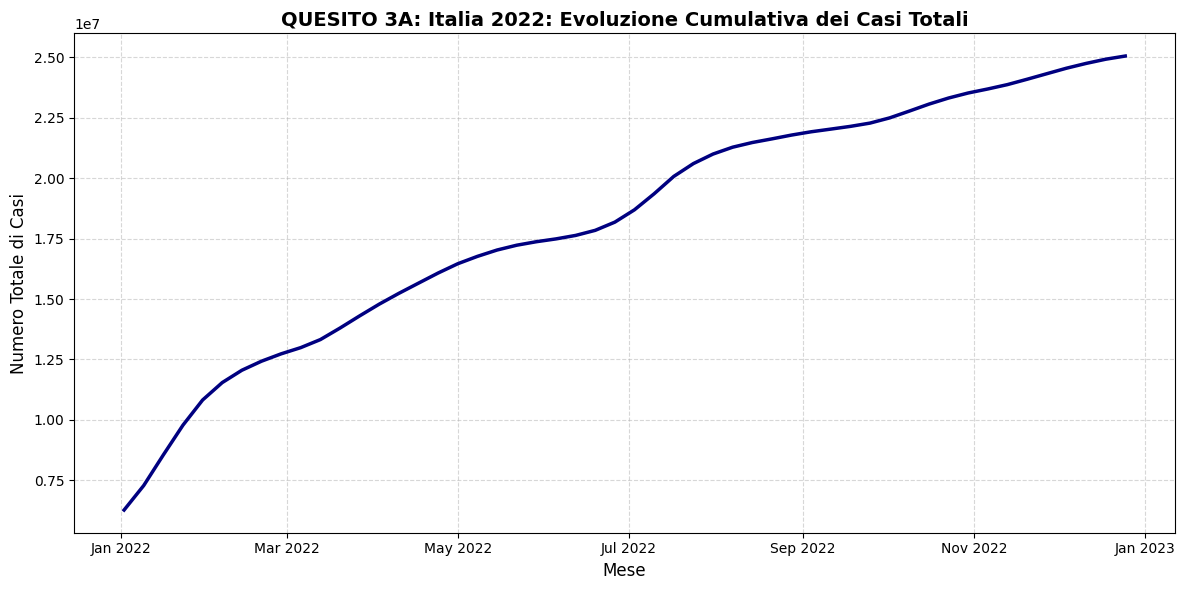

<Figure size 640x480 with 0 Axes>

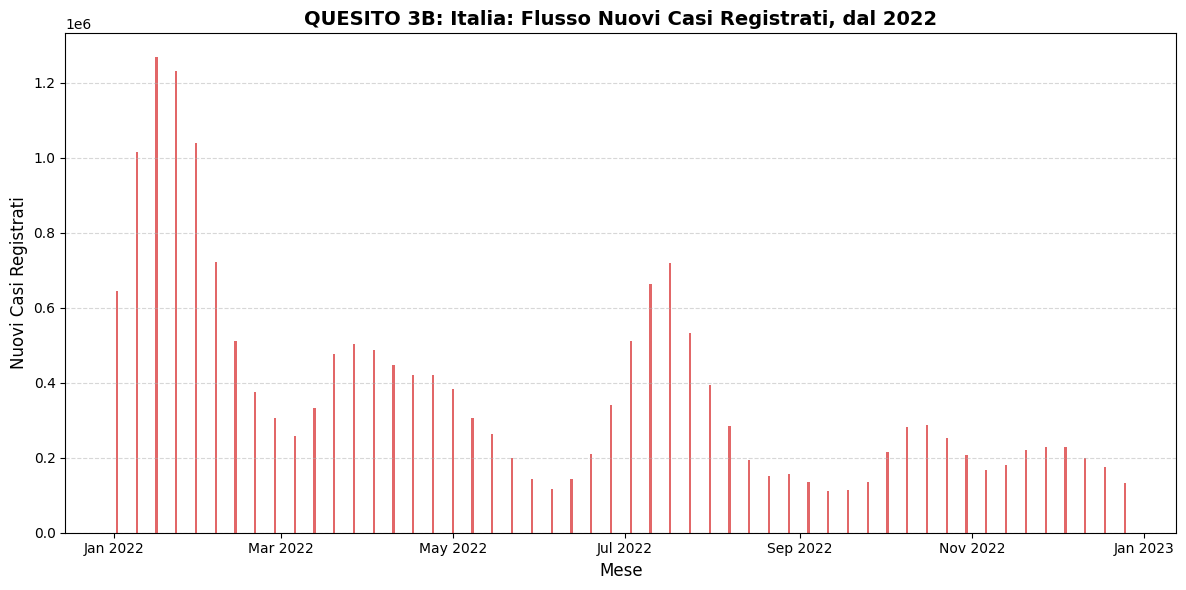

<Figure size 640x480 with 0 Axes>

In [ ]:


df_italia_2022 = df_clean[(df_clean['location'] == 'Italy') & (df_clean['date'].dt.year == 2022)].copy() # estrapoliamo dove è presente il data "Italia" e "2022", creando una copia per non corrompere i dati globali
df_italia_2022 = df_italia_2022[(df_italia_2022['new_cases'].notna()) & (df_italia_2022['new_cases'] > 0)] # Teniamo solo le righe dove: new_case sia notNaN e che sia > 0

print(f"\n--- ITALIA 2022 ---")
print(f"Giorni con misurazioni effettive per l'Italia nel 2022: {len(df_italia_2022)}")

# 3a. Evoluzione dei casi totali (Grafico a linee)
plt.figure(figsize=(12, 6))
plt.plot(df_italia_2022['date'], df_italia_2022['total_cases'], color='navy', linewidth=2.5)
plt.title("QUESITO 3A: Italia 2022: Evoluzione Cumulativa dei Casi Totali", fontsize=14, fontweight='bold')
plt.xlabel("Mese", fontsize=12)
plt.ylabel("Numero Totale di Casi", fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig('QUESITO 3A: evoluzione_casi_totali_italia_2022.png')

# 3b. Numero di nuovi casi rispetto alla data (Grafico a barre per flussi discreti)
plt.figure(figsize=(12, 6))
plt.bar(df_italia_2022['date'], df_italia_2022['new_cases'], color='tab:red', alpha=0.7)
plt.title("QUESITO 3B: Italia: Flusso Nuovi Casi Registrati, dal 2022", fontsize=14, fontweight='bold')
plt.xlabel("Mese", fontsize=12)
plt.ylabel("Nuovi Casi Registrati", fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig('QUESITO 3B: Italia: Flusso Nuovi Casi Registrati, dal 2022.png')

# 4. Riguardo le nazioni di Italia, Germania e Francia:
    4a. mostrare in un boxplot la differenza tra queste nazioni riguardo il numero di pazienti in terapia intensiva (Intensive Care Unit, ICU, considerare quindi la colonna icu_patients) da maggio 2022 (incluso) ad aprile 2023 (incluso)

    4b.  scrivere un breve commento (una o due righe) riguardo che conclusioni possiamo trarre osservando il grafico risultante

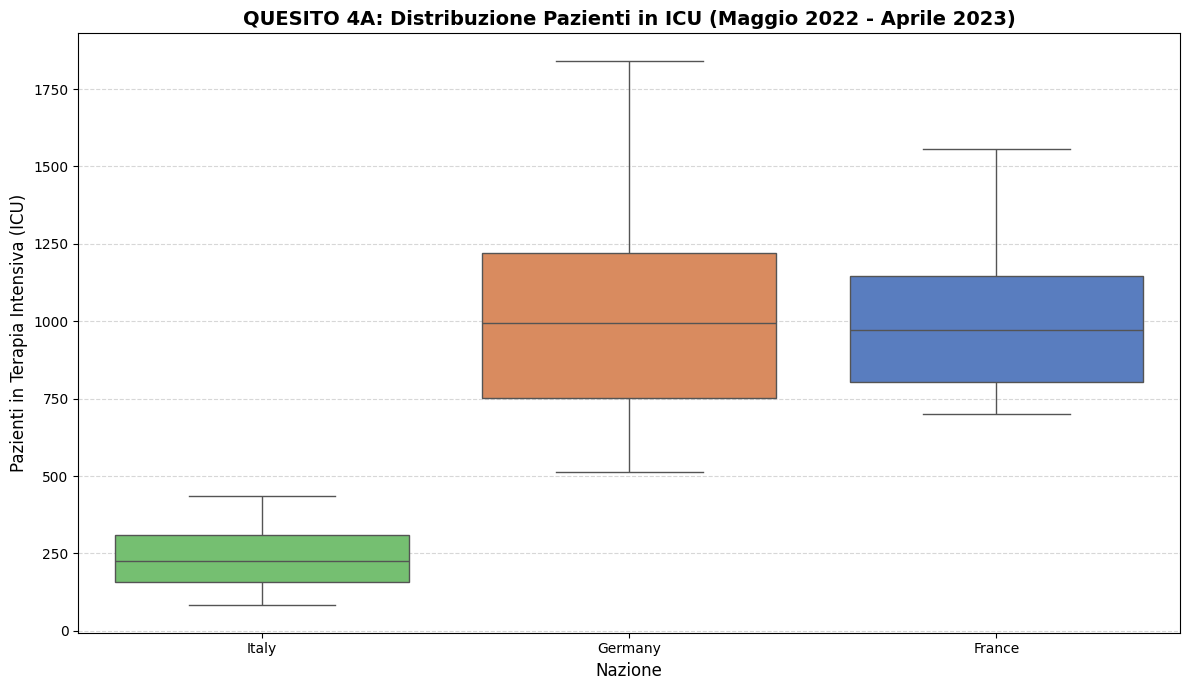


--- QQUESITO 4A: Distribuzione Pazienti in ICU (Maggio 2022 - Aprile 2023) tra Italia,  Germania e Francia ---
 QUESITO 4B: : La Germania mostra un carico mediano strutturalmente superiore e una deviazione standard molto più ampia. Italia e Francia presentano una pressione ospedaliera intensiva più contenuta e uniforme, suggerendo una diversa gestione dei flussi critici o criteri di ammissione differenti nel periodo analizzato.


<Figure size 640x480 with 0 Axes>

In [ ]:
# Definizione nazioni e tempo richiesto dal quesito.
nazioni_icu = ['Italy', 'Germany', 'France']
data_inizio = '2022-05-01'
data_fine = '2023-04-30'

df_icu = df_clean[(df_clean['location'].isin(nazioni_icu)) & # contenitore, li interseghiamo "locatione" e "date" tra loro
                  (df_clean['date'].between(data_inizio, data_fine))].copy() # creamo una copia per non compromettere i file originali

# 4a. Boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='location', y='icu_patients', hue='location', data=df_icu, order=nazioni_icu, palette="muted", fliersize=3) # associando dei colori alla variabile dell'asse X.
plt.title("QUESITO 4A: Distribuzione Pazienti in ICU (Maggio 2022 - Aprile 2023)", fontsize=14, fontweight='bold')
plt.xlabel("Nazione", fontsize=12)
plt.ylabel("Pazienti in Terapia Intensiva (ICU)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
plt.savefig('QUESITO 4A: Distribuzione Pazienti in ICU (Maggio 2022 - Aprile 2023) tra Italia,  Germania e Francia.png')

# QUESITO 4B
La Germania mostra un carico mediano strutturalmente superiore e una deviazione standard molto più ampia. Italia e Francia presentano una pressione ospedaliera intensiva più contenuta e uniforme, suggerendo una diversa gestione dei flussi critici o criteri di ammissione differenti nel periodo analizzato.

# 5. Riguardo le nazioni di Italia, Germania, Francia e Spagna in tutto il 2021:
    5a. mostrare, in maniera grafica oppure numerica, la somma dei pazienti ospitalizzati per ognuna (colonna hosp_patients)

    5b. se ci sono dati nulli, con un breve commento scrivere se può essere possibile gestirli tramite sostituzione o meno.

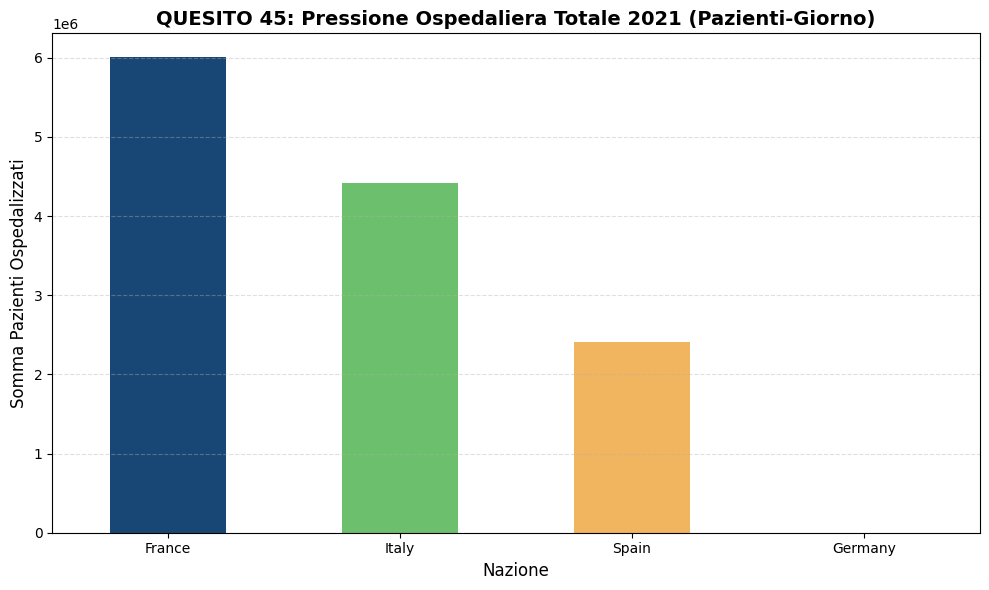


--- QUESITO 5A: OSPEDALIZZAZIONI 2021 ---
Ospedalizzazioni totali per France: 6,008,717 pazienti-giorno.
Ospedalizzazioni totali per Italy: 4,419,950 pazienti-giorno.
Ospedalizzazioni totali per Spain: 2,411,706 pazienti-giorno.
Ospedalizzazioni totali per Germany: 0 pazienti-giorno.

--- QUESITO 5B: GESTIONE LACUNE (CRITICA) ---
Stato integrità Italy: 0 giorni con dati nulli su 365 misurazioni.
Stato integrità Germany: 365 giorni con dati nulli su 365 misurazioni.
Stato integrità France: 0 giorni con dati nulli su 365 misurazioni.
Stato integrità Spain: 0 giorni con dati nulli su 365 misurazioni.


<Figure size 640x480 with 0 Axes>

In [ ]:
nazioni_euro4 = ['Italy', 'Germany', 'France', 'Spain'] # lista quattro nazioni richieste
df_2021 = df_clean[(df_clean['location'].isin(nazioni_euro4)) & (df_clean['date'].dt.year == 2021)].copy() # contenitore, filtrato nel tempo 2021


# 5a. Somma dei pazienti ospedalizzati (pazienti-giorno)
ospedalizzazioni_totali = df_2021.groupby('location')['hosp_patients'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ospedalizzazioni_totali.plot(kind='bar', color=['#003366', '#5cb85c', '#f0ad4e', '#d9534f'], alpha=0.9)
plt.title("QUESITO 45: Pressione Ospedaliera Totale 2021 (Pazienti-Giorno)", fontsize=14, fontweight='bold')
plt.xlabel("Nazione", fontsize=12)
plt.ylabel("Somma Pazienti Ospedalizzati", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
plt.savefig('QUESITO 5: Pressione Ospedaliera Totale 2021 (Pazienti-Giorno).png')


print(f"\n--- QUESITO 5A: OSPEDALIZZAZIONI 2021 ---")
for nazione, totale in ospedalizzazioni_totali.items(): # Ciclo iterativo per stampare i valori esatti estratti dal grafico
    print(f"Ospedalizzazioni totali per {nazione}: {totale:,.0f} pazienti-giorno.")

# 5b. Diagnostica dei vuoti
dati_nulli = df_2021.groupby('location')['hosp_patients'].apply(lambda x: x.isnull().sum())

print(f"\n--- QUESITO 5B: GESTIONE LACUNE (CRITICA) ---")
for nazione in nazioni_euro4: # ciclo di verifica incrociata. Calcoliamo i giorni totali presenti per ogni nazione e stampiamo il rapporto esatto tra giorni nulli e giorni tracciati.
    giorni_totali = len(df_2021[df_2021['location'] == nazione])
    print(f"Stato integrità {nazione}: {dati_nulli[nazione]} giorni con dati nulli su {giorni_totali} misurazioni.")


# IL RISULTATO
il risultato è inattaccabile sull'impossibilità di imputare i dati della Germania, proteggendo la validità del report.

Per la Germania, la totalità dei dati 'hosp_patients' nel 2021 è mancante. Matematicamente e operativamente, è IMPOSSIBILE gestire questa lacuna tramite tecniche di sostituzione (come l'imputazione della media o l'interpolazione) senza fabbricare un dato inesistente. La nazione va metodologicamente esclusa dal confronto quantitativo per questa specifica metrica.


Nuzzo